In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv('survey.csv')
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [6]:
# Check information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [9]:
# Check missing values
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [14]:
# Fixing the irregular columns
df["Gender"] = df["Gender"].str.lower().str.strip()
# Replace common variants
df['Gender'] = df['Gender'].replace({
    'male': 'male',
    'm': 'male',
    'man': 'male',
    'female': 'female',
    'f': 'female',
    'woman': 'female',
    'cis female': 'female',
    'cis male': 'male',
    'trans female': 'trans',
    'trans male': 'trans',
    'genderqueer': 'non-binary',
    'non-binary': 'non-binary',
    'agender': 'non-binary',
    'other': 'non-binary',
    'male-ish': 'male',
    'queer': 'non-binary',
    'fluid': 'non-binary',
    'genderfluid': 'non-binary'
    })
valid_genders = ["male","female","trans","non-binary"]
df["Gender"] = df["Gender"].apply(lambda x: x if x in valid_genders else "other")
df.sample(9)

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
594,2014-08-27 22:12:55,29,male,United States,OR,No,Yes,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
946,2014-08-29 00:06:49,45,male,United States,NY,No,No,No,NaN,More than 1000,...,Don't know,No,No,Some of them,Some of them,No,No,Yes,No,NaN
321,2014-08-27 14:28:43,29,male,United States,CA,No,No,Yes,Sometimes,More than 1000,...,Don't know,Yes,No,Some of them,Some of them,No,Maybe,No,No,NaN
747,2014-08-28 11:10:53,32,male,Italy,NaN,No,No,No,NaN,6-25,...,Somewhat difficult,Maybe,No,Some of them,No,Maybe,Maybe,No,No,Italians are somewhat behind for what concerns...
1082,2014-08-29 16:17:32,30,female,United States,TN,No,Yes,Yes,Often,More than 1000,...,Somewhat difficult,Yes,No,No,No,No,Maybe,No,No,This issue for me is very real at the moment. ...
796,2014-08-28 13:26:17,32,female,United States,CA,No,Yes,Yes,Often,100-500,...,Don't know,Yes,No,Some of them,Yes,No,No,Don't know,No,NaN
678,2014-08-28 08:40:55,29,male,Germany,NaN,Yes,No,No,NaN,1-5,...,Very easy,No,No,Yes,Yes,Yes,Yes,Yes,No,NaN
479,2014-08-27 16:17:05,30,female,United States,NY,No,No,No,NaN,100-500,...,Don't know,Maybe,No,Some of them,Yes,No,Maybe,Don't know,No,NaN
466,2014-08-27 16:06:46,57,male,United States,CA,No,Yes,Yes,Rarely,More than 1000,...,Don't know,Maybe,No,Some of them,Yes,No,Maybe,No,No,NaN


In [15]:
df["Age"].describe()
df = df[(df["Age"] >= 10 & (df["Age"] <= 100 ))]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1256 non-null   object
 1   Age                        1256 non-null   int64 
 2   Gender                     1256 non-null   object
 3   Country                    1256 non-null   object
 4   state                      742 non-null    object
 5   self_employed              1238 non-null   object
 6   family_history             1256 non-null   object
 7   treatment                  1256 non-null   object
 8   work_interfere             993 non-null    object
 9   no_employees               1256 non-null   object
 10  remote_work                1256 non-null   object
 11  tech_company               1256 non-null   object
 12  benefits                   1256 non-null   object
 13  care_options               1256 non-null   object
 14  wellness_prog

In [18]:
# Check for missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

comments          1093
state              514
work_interfere     263
self_employed       18
dtype: int64

In [23]:
# Fixing missing values
#df.drop(columns=["comments"],inplace=True)
#df["state"].fillna("Unknown",inplace=True)
#df["work_interfere"].fillna("Unknown",inplace=True)
#df["self_employed"].fillna("Unknown",inplace=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 0 to 1258
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1256 non-null   object
 1   Age                        1256 non-null   int64 
 2   Gender                     1256 non-null   object
 3   Country                    1256 non-null   object
 4   state                      1256 non-null   object
 5   self_employed              1256 non-null   object
 6   family_history             1256 non-null   object
 7   treatment                  1256 non-null   object
 8   work_interfere             1256 non-null   object
 9   no_employees               1256 non-null   object
 10  remote_work                1256 non-null   object
 11  tech_company               1256 non-null   object
 12  benefits                   1256 non-null   object
 13  care_options               1256 non-null   object
 14  wellness_prog

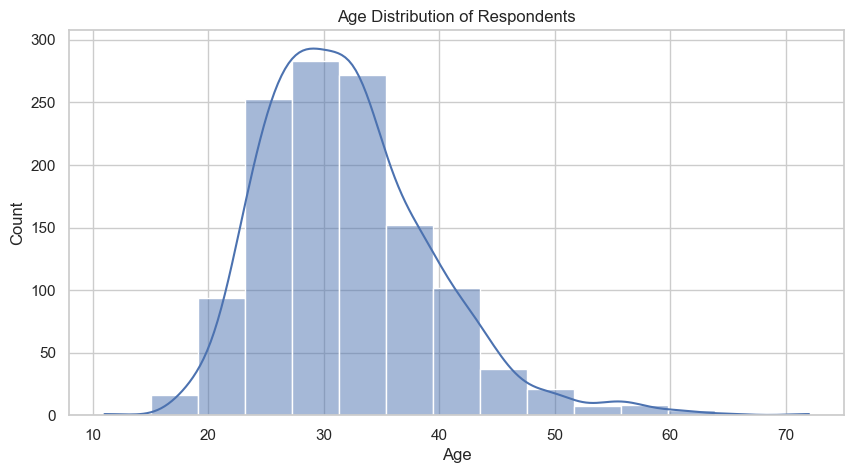

In [68]:
age_data = df['Age']
age_data = age_data[pd.to_numeric(age_data, errors='coerce').notna()]  # Keep numeric values
age_data = age_data.astype(float)
age_data = age_data[(age_data >= 10) & (age_data <= 100)]  # Filter out extreme values

plt.figure(figsize=(10, 5))
sns.histplot(age_data, bins=15, kde=True)
plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

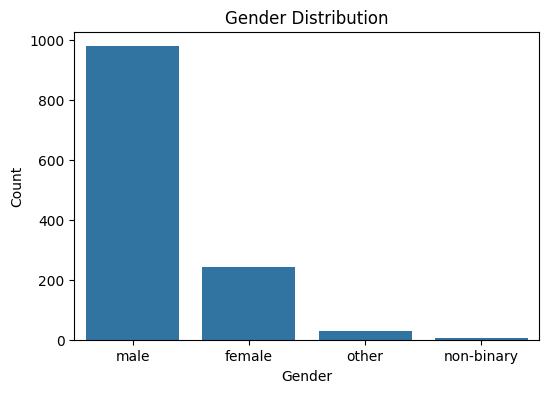

In [60]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, order=df['Gender'].value_counts().index)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

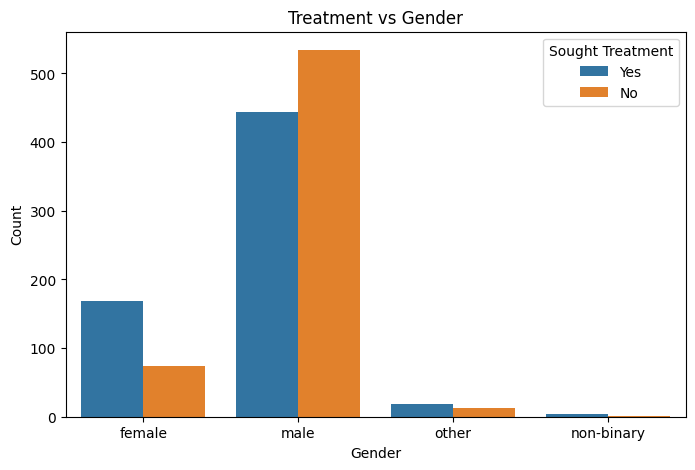

In [61]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='treatment', data=df)
plt.title('Treatment vs Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

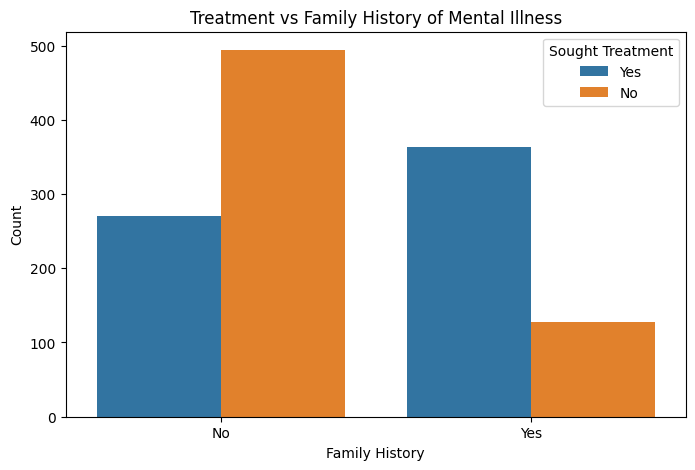

In [62]:
plt.figure(figsize=(8, 5))
sns.countplot(x='family_history', hue='treatment', data=df)
plt.title('Treatment vs Family History of Mental Illness')
plt.xlabel('Family History')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

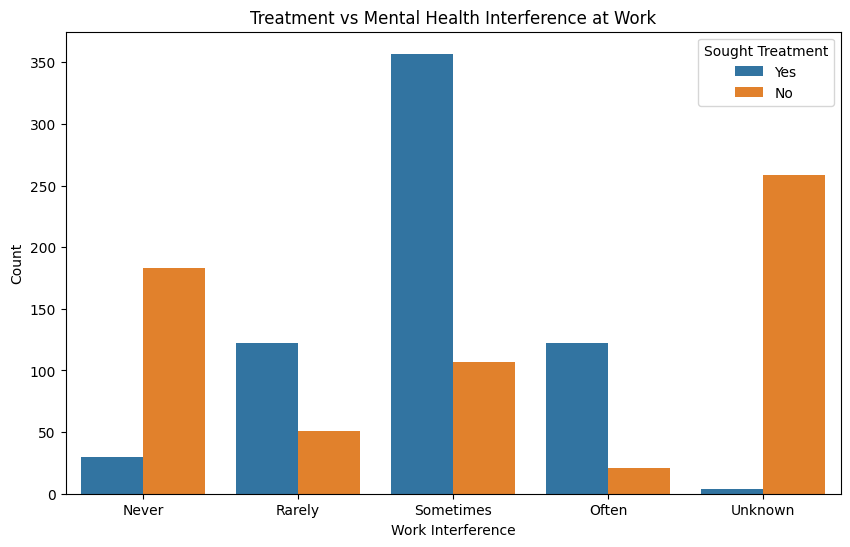

In [63]:
plt.figure(figsize=(10, 6))
sns.countplot(x='work_interfere', hue='treatment', data=df,
              order=['Never', 'Rarely', 'Sometimes', 'Often', 'Unknown'])
plt.title('Treatment vs Mental Health Interference at Work')
plt.xlabel('Work Interference')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

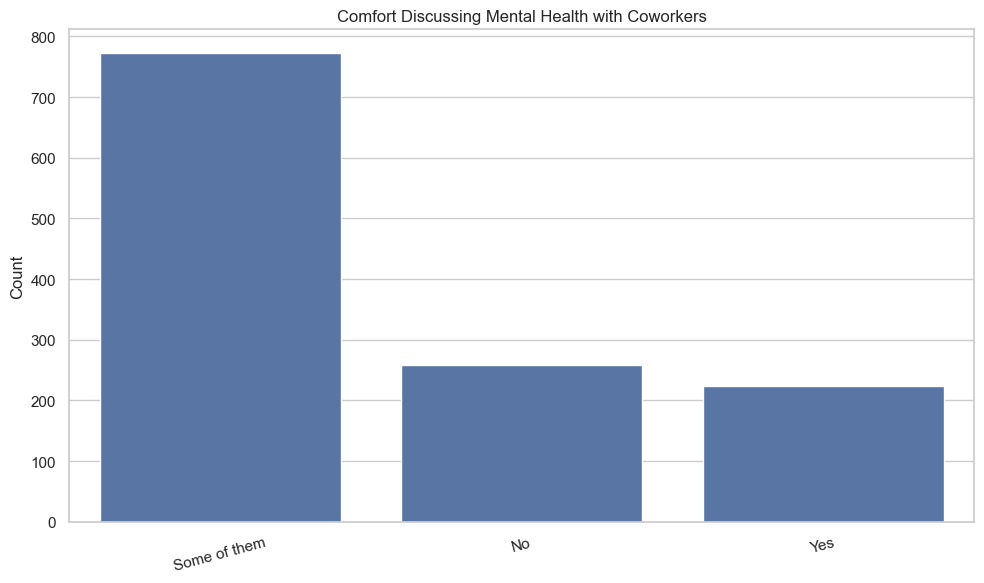

In [64]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='coworkers', order=df['coworkers'].value_counts().index)
plt.title("Comfort Discussing Mental Health with Coworkers")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

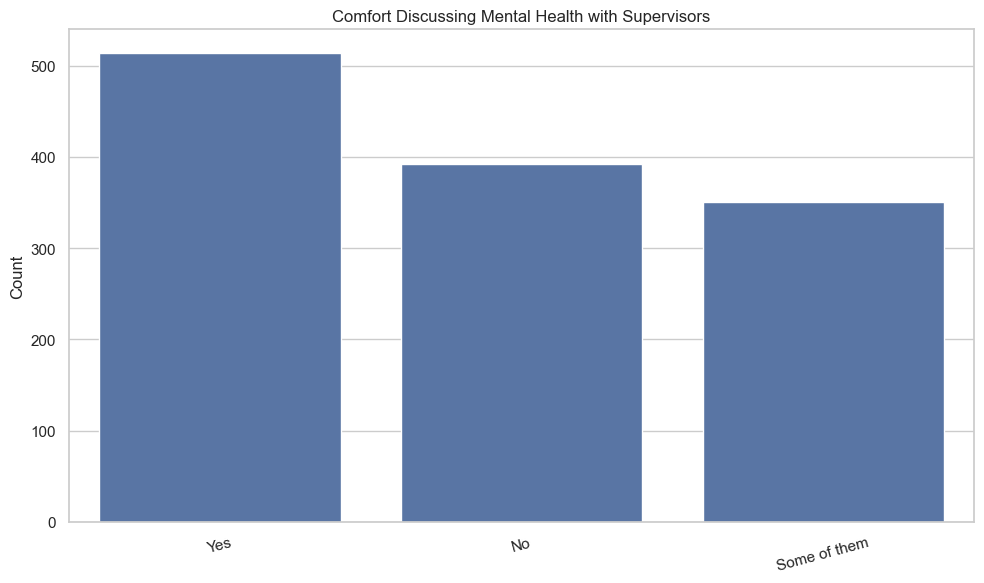

In [65]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='supervisor', order=df['supervisor'].value_counts().index)
plt.title("Comfort Discussing Mental Health with Supervisors")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

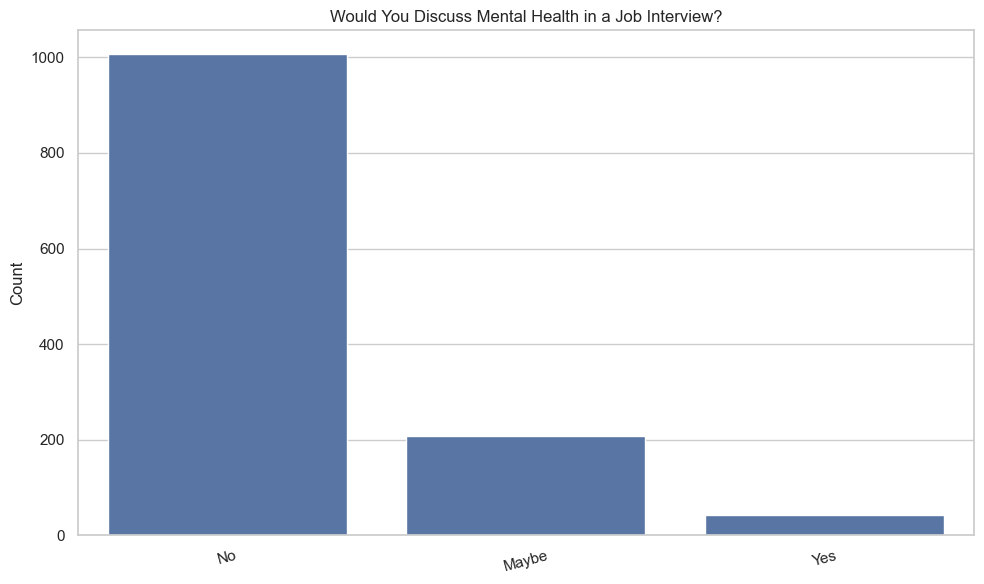

In [66]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='mental_health_interview', order=df['mental_health_interview'].value_counts().index)
plt.title("Would You Discuss Mental Health in a Job Interview?")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

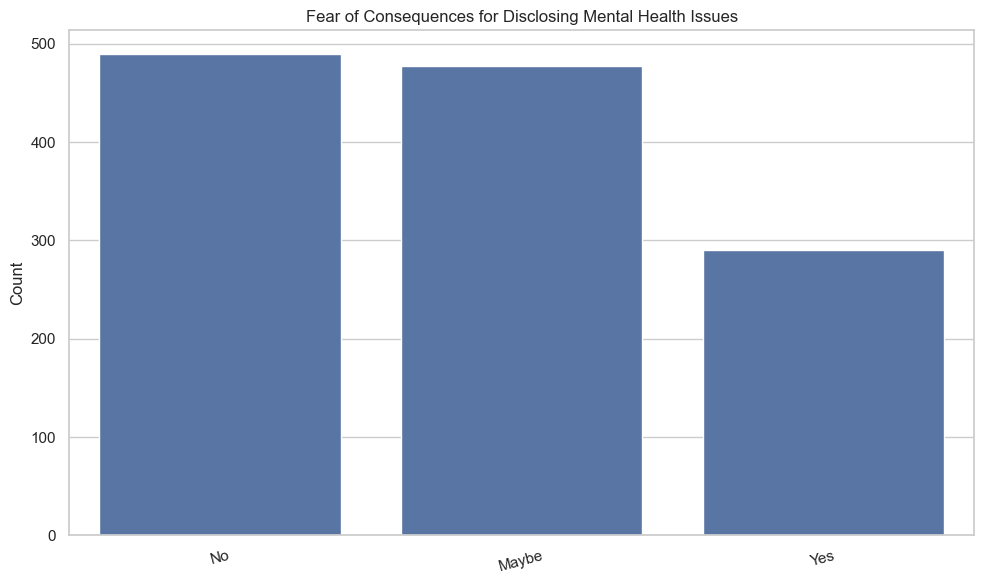

In [67]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='mental_health_consequence', order=df['mental_health_consequence'].value_counts().index)
plt.title("Fear of Consequences for Disclosing Mental Health Issues")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


✅ Conclusion
The findings point to a clear need for more inclusive mental health policies in the tech industry. Efforts should be made to:
Normalize conversations around mental health.


Train leaders to respond empathetically.


Create safe environments for disclosure.


Promote equitable support systems regardless of gender or background.


A data-driven approach like this can help employers build more supportive and productive workplaces by putting mental health at the center of organizational culture.

